In [ ]:
%load_ext autoreload
%autoreload 2

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cns.data_utils import load_cns_out
from cns.process import bin_by_break_type, mean_bins, add_seg_info
from cns.utils.selection import cns_head
from cns.display import fig_line, fig_scatter
from cns.utils import hg19

In [36]:
pcawg_cns_df = load_cns_out("PCAWG_cns_imp.tsv")

In [37]:
pcawg_1_bin_df = bin_by_break_type(cns_head(pcawg_cns_df, 1), 100_000)
pcawg_1_groups_df = mean_bins(pcawg_1_bin_df)

pcawg_10_bin_df = bin_by_break_type(cns_head(pcawg_cns_df, 10), 1_000_000)
pcawg_10_groups_df = mean_bins(pcawg_10_bin_df)

pcawg_50_bin_df = bin_by_break_type(cns_head(pcawg_cns_df, 50), 10_000_000)
pcawg_50_groups_df = mean_bins(pcawg_50_bin_df)

subset_arms = bin_by_break_type(cns_head(pcawg_cns_df, 10), "arms")
subset_arms_groups = mean_bins(subset_arms)

Binning chr (23/23)
Binning chr (231/231)
Binning chr (1151/1151)
Binning chr (231/231)


In [38]:
pcawg_10_bin_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn
0,SP1003,chr1,0,1001007,2.0,2.0
1,SP1003,chr1,1001007,2002013,2.0,2.0
2,SP1003,chr1,2002013,3003020,2.0,2.0
3,SP1003,chr1,3003020,4004026,2.0,2.0
4,SP1003,chr1,4004026,5005033,2.0,2.0


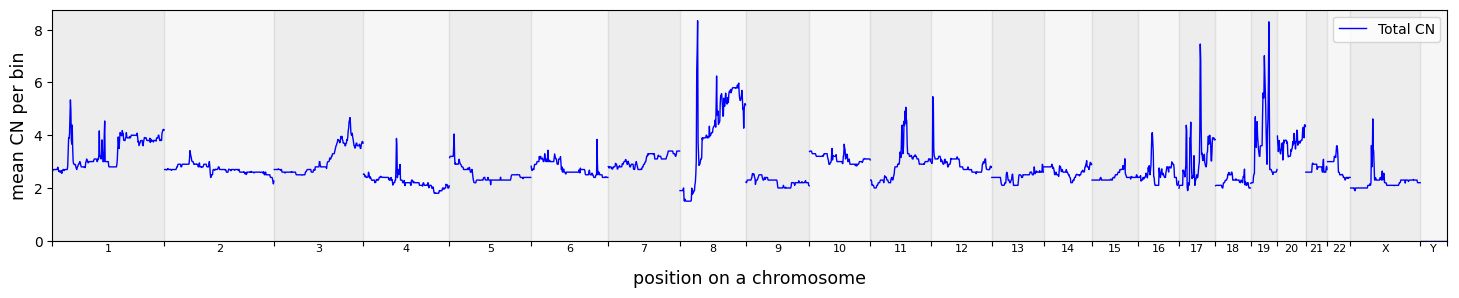

In [76]:
max_cn = np.ceil(pcawg_10_groups_df["total_cn"].max())
fig_line(pcawg_10_groups_df, column="total_cn", label="Total CN", color="blue");

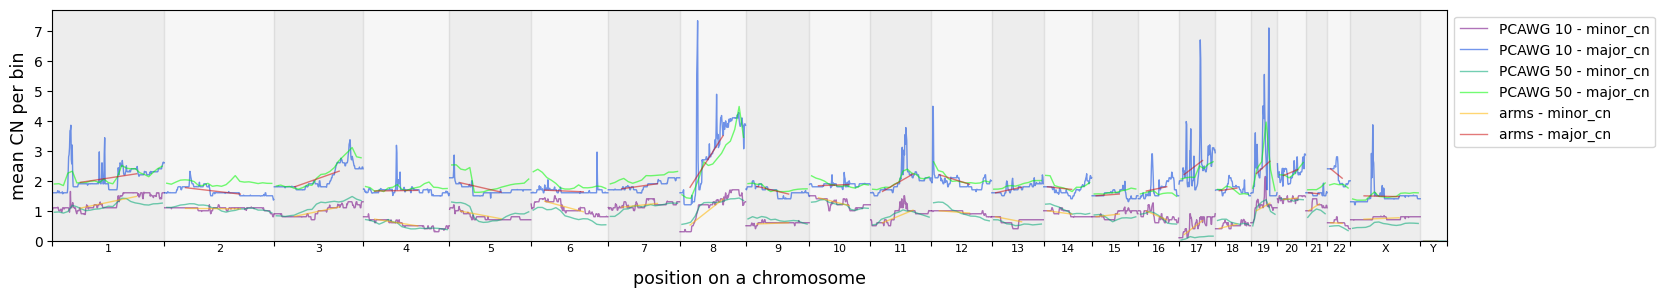

In [77]:
fig, ax = fig_line([pcawg_10_groups_df, pcawg_50_groups_df, subset_arms_groups], label=["PCAWG 10", "PCAWG 50", "arms"], column=["minor_cn", "major_cn"])

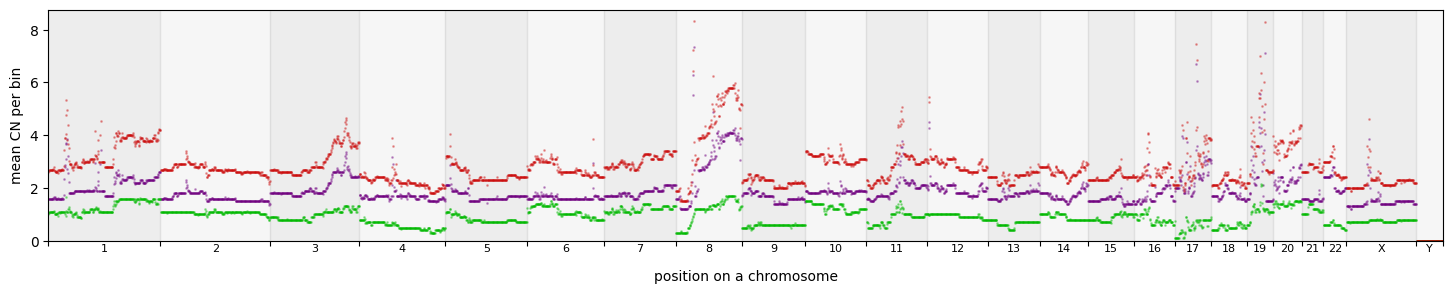

In [90]:
fig_scatter(pcawg_10_groups_df);

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on a chromosome', ylabel='mean CN per bin'>)

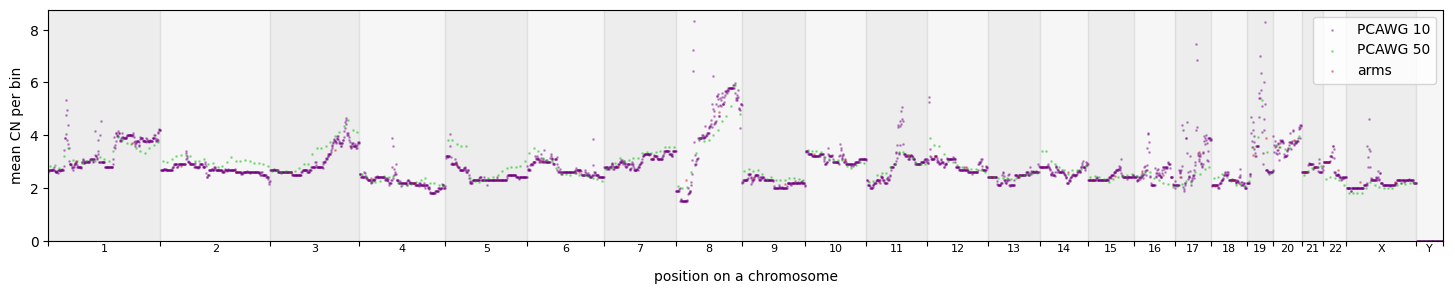

In [92]:
fig_scatter([pcawg_10_groups_df, pcawg_50_groups_df, subset_arms_groups], ["PCAWG 10", "PCAWG 50", "arms"], column="total_cn")

In [32]:
step_size = int(1e6)
# only keep gaps at least half the step size
gaps_hg19_segs = tuples_to_segments(hg19.gaps)
genome_segs = genome_to_segments(hg19.chr_lens)
merged_hg19_gaps = merge_segments(gaps_hg19_segs)
filtered_gaps = filter_min_size(merged_hg19_gaps, step_size // 2)
filtered_genome = segment_difference(genome_segs, filtered_gaps)
filtered_segs = split_segments(filtered_genome, step_size)
filtered_cns = bin_by_segments(cns_head(pcawg_cns_df, 10), filtered_segs)

Binning chr (231/231)


Text(0.5, 1.0, 'Mean Copy Number across the genome, gaps removed')

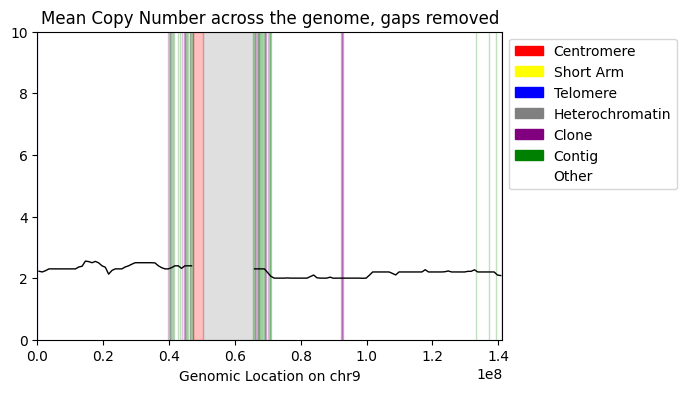

In [33]:
with_loc = add_seg_info(filtered_cns)
grouped_bins = mean_bins(with_loc)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=100)
plot_gaps(ax, alpha=.25, y_max=10, sel_chrom="chr9")
add_gap_legend(ax)
line_plot(ax, grouped_bins, "total_cn", color="black", chrom="chr9")
# no_y_ticks(ax)
# add lables
ax.set_xlabel("Genomic Location on chr9")
# ax.set_ylabel("Mean Copy Number")
ax.set_title("Mean Copy Number across the genome, gaps removed")

# CN Tracks

Figure size in inches: [10.   1.2] (Width x Height)
Ax size in inches: [8.43479167 0.6016003 ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.07826041666666661
	Bottom: 0.2493332070831824
	Right: 0.9217395833333334
	Top: 0.7506667929168176
image_pixes:  (607, 30363)
dpi:  100
Top size:  0.125


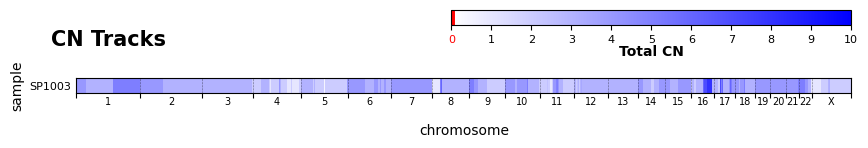

In [34]:
fig_CN_heatmap(pcawg_1_bin_df, print_info=True, dpi=100)

Figure size in inches: [10.   1.2] (Width x Height)
Ax size in inches: [8.43479167 0.6016003 ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.07826041666666661
	Bottom: 0.2493332070831824
	Right: 0.9217395833333334
	Top: 0.7506667929168176
image_pixes:  (607, 30363)
dpi:  100
Top size:  0.125


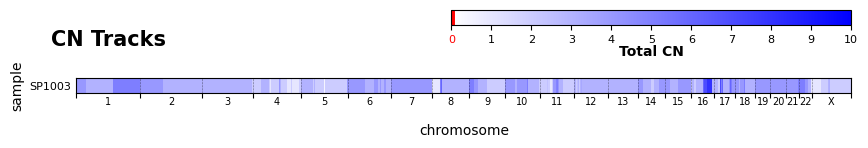

In [35]:
fig_CN_heatmap(pcawg_1_bin_df, print_info=True)

Figure size in inches: [10.  3.] (Width x Height)
Ax size in inches: [8.57729167 2.06125   ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.07113541666666662
	Bottom: 0.1564583333333333
	Right: 0.9288645833333333
	Top: 0.8435416666666666
image_pixes:  (10, 48)
dpi:  100
Top size:  0.05


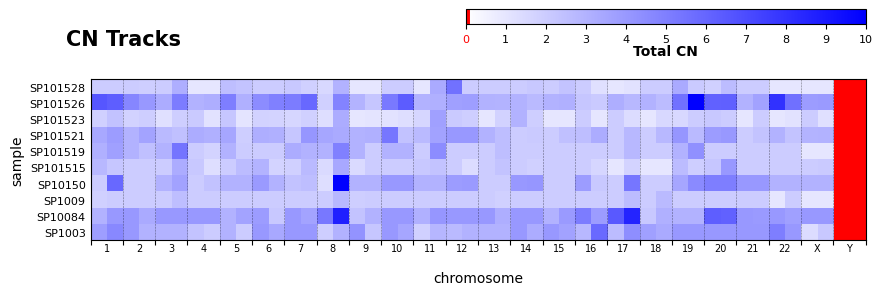

In [36]:
fig_CN_heatmap(subset_arms, width=10, print_info=True)

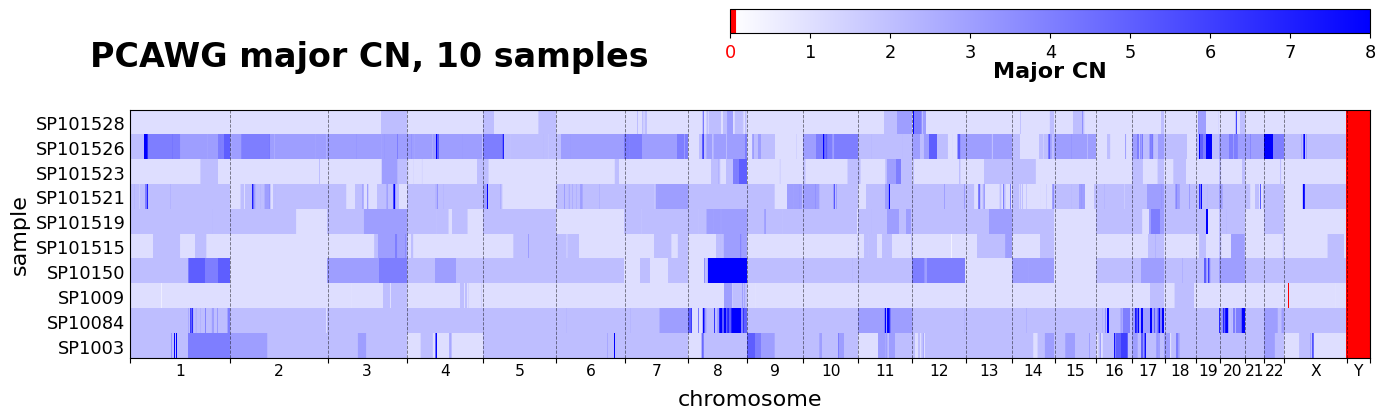

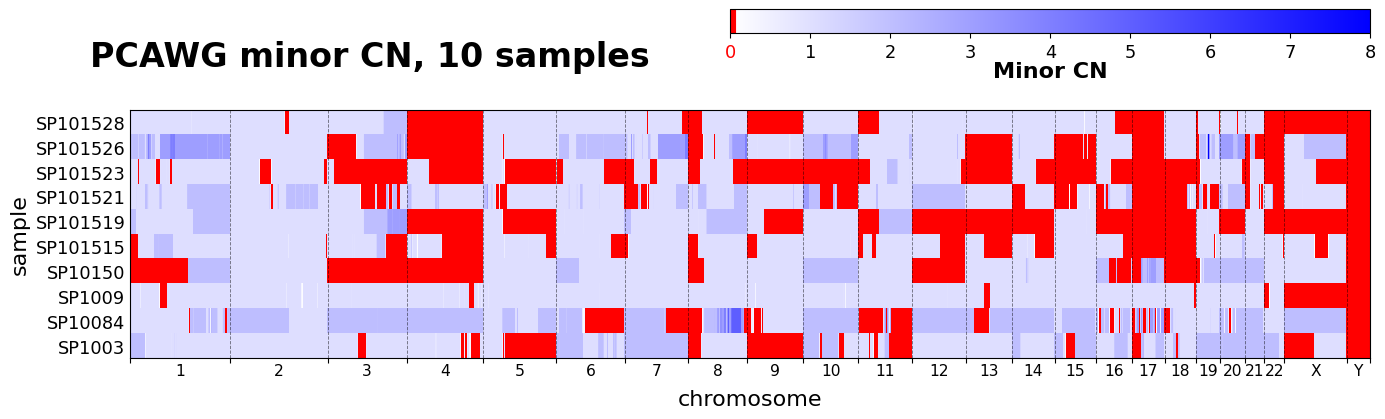

In [37]:
fig_CN_heatmap(pcawg_10_bin_df, "PCAWG major CN, 10 samples", width=16, cn_column="major_cn", max_cn=8)
fig_CN_heatmap(pcawg_10_bin_df, "PCAWG minor CN, 10 samples", width=16, cn_column="minor_cn", max_cn=8)

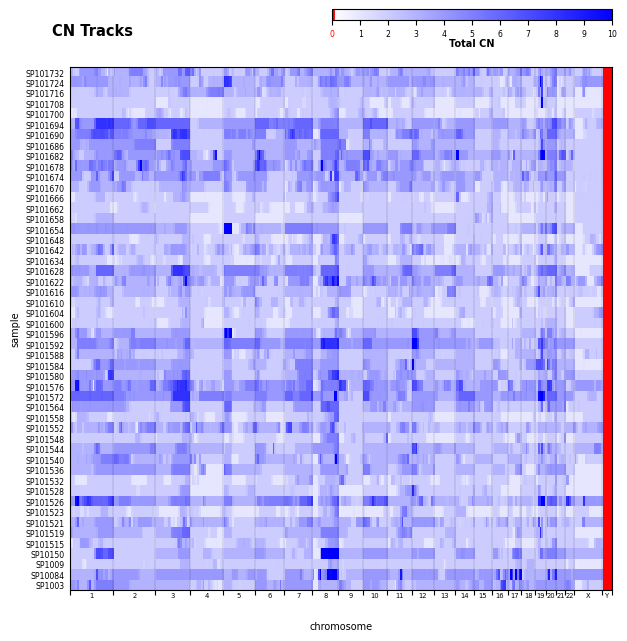

In [38]:
fig_CN_heatmap(pcawg_50_bin_df, width=7)

In [39]:
pcawg_500_bin_df = bin_by_break_type(cns_head(pcawg_cns_df, 500), 10_000_000)
print("Creating heatmap.... ")
fig_CN_heatmap(pcawg_500_bin_df, vertical_legend_correction=0.0025);
# create directory out if not exist

plt.savefig(pjoin(out_path, "pcawg_500_tracks.png"), dpi=150)
plt.close()

Binning chr (11784/11784)
Creating heatmap.... 
